In [1]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import datetime

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [4]:
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [5]:
model = Sequential([
    Dense(128, input_shape=(X_train_scaled.shape[1],)),
    LeakyReLU(alpha=0.1),
    Dense(64),
    LeakyReLU(alpha=0.1),
    Dense(32),
    Dense(1)
])

c:\Users\kseni\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kseni\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [6]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    callbacks=[tensorboard_callback, EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 4064.1240 - mae: 62.5099 - val_loss: 661.5670 - val_mae: 21.7854
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 457.2523 - mae: 17.5464 - val_loss: 135.1586 - val_mae: 9.1084
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 142.2627 - mae: 9.4086 - val_loss: 92.3576 - val_mae: 7.5498
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 92.1043 - mae: 7.5862 - val_loss: 72.5236 - val_mae: 6.7283
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 88.2738 - mae: 7.3477 - val_loss: 63.2684 - val_mae: 6.1908
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70.2697 - mae: 6.5037 - val_loss: 54.7831 - val_mae: 5.8265
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 63.1046 - mae: 6.2217 - val_loss: 53.1609 - val_mae: 5.7322
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 60.3763 - mae: 6.0893 - val_loss: 44.1606 - val_mae: 5.2015
Epoch 9/100
47/47 ━━━━━━━━━━━━━━━━━━━━

In [7]:
y_pred = model.predict(X_test_scaled).flatten()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [8]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")

MSE: 6.165635585784912
MAE: 1.7879714965820312
R2 Score: 0.9286885261535645


In [9]:
import json

metrics = {
    "MAE": mae,
    "MSE": mse,
    "R2": r2
}

with open(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\metrics\neural_network_metrics.json", "w") as f:
    json.dump(metrics, f)

In [10]:
import pickle

with open(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\models\neural_network_model.pkl", "wb") as f:
    pickle.dump(model, f)

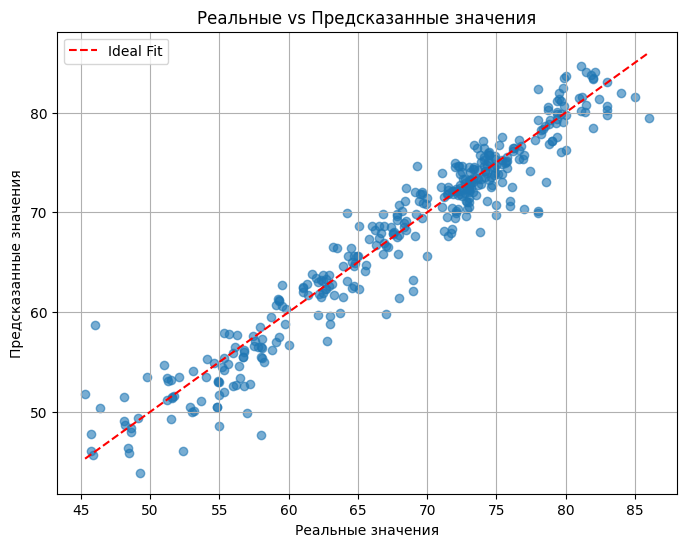

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Ideal Fit')
plt.title("Реальные vs Предсказанные значения")
plt.xlabel("Реальные значения")
plt.ylabel("Предсказанные значения")
plt.legend()
plt.grid(True)

plt.savefig(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\models\neural_network\1.png", dpi=300, bbox_inches="tight")
plt.show()

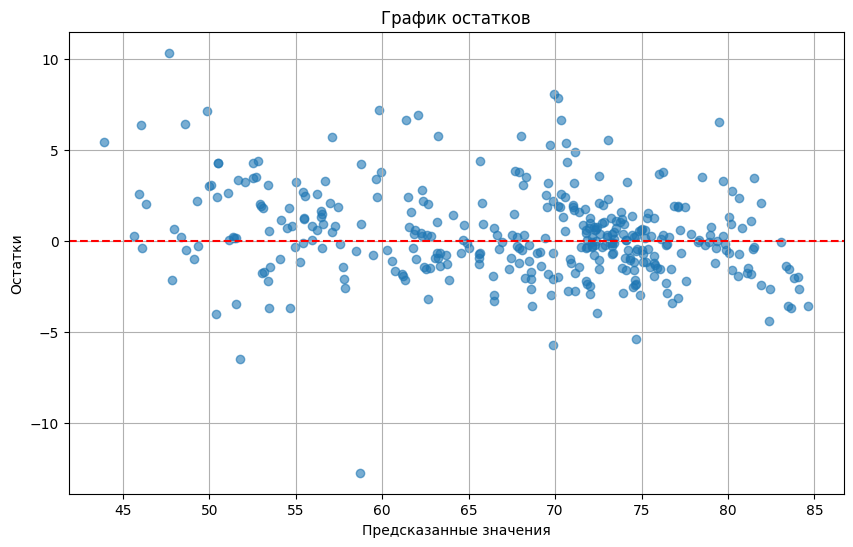

In [12]:
residuals = y_test.values.flatten() - y_pred.flatten()

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков')
plt.grid(True)

plt.savefig(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\models\neural_network\2.png", dpi=300, bbox_inches="tight")
plt.show()

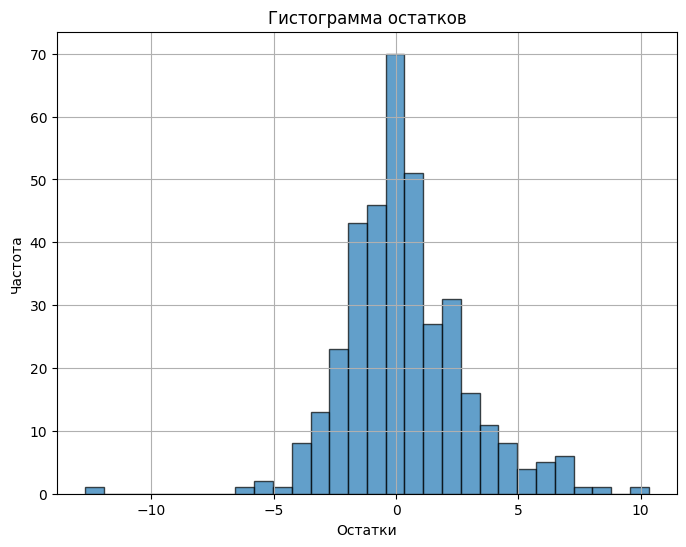

In [13]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title("Гистограмма остатков")
plt.xlabel("Остатки")
plt.ylabel("Частота")
plt.grid(True)

plt.savefig(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\models\neural_network\3.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
print(f"tensorboard --logdir {log_dir}")

tensorboard --logdir logs/fit/20250124-075829
